
# Probability in Financial Data: Rare Events, Markov, and Chebyshev

### Python Notebook for ASDA I Discussion Session

This notebook uses daily S&P 500 index data to connect three probability ideas to a real dataset:

1. **Poisson distribution:** model the number of rare market-movement events in a fixed block of trading days.
2. **Markov's inequality:** bound the probability of a large nonnegative quantity using only its mean.
3. **Chebyshev's inequality:** bound the probability of a large deviation using the mean and variance.

The dataset is obtained from [Kaggle](https://www.kaggle.com/datasets/henryhan117/sp-500-historical-data/data), once you have downloaded the dataset, make sure it lives in the same folder as this notebook.



## Package Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import poisson, norm, t, uniform

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True



## 1. Load the S&P 500 data

We use the S&P 500 index data from 1927-2020

The historical-data interface provides daily Open, High, Low, Close, Adjusted Close, and Volume observations.

We will use the **adjusted close** when available, because returns should account for distributions as well as changes in the index level.


In [3]:
df = pd.read_csv('SPX.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1927-12-30,17.660000,17.660000,17.660000,17.660000,17.660000,0
1,1928-01-03,17.760000,17.760000,17.760000,17.760000,17.760000,0
2,1928-01-04,17.719999,17.719999,17.719999,17.719999,17.719999,0
3,1928-01-05,17.549999,17.549999,17.549999,17.549999,17.549999,0
4,1928-01-06,17.660000,17.660000,17.660000,17.660000,17.660000,0


The "Volume" denotes Number of shares traded, so let's make it more fun:

In [8]:
data = df[df["Volume"]!=0]

data = data.copy()

data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date")
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
5496,1950-01-03,16.66,16.66,16.66,16.66,16.66,1260000
5497,1950-01-04,16.85,16.85,16.85,16.85,16.85,1890000
5498,1950-01-05,16.93,16.93,16.93,16.93,16.93,2550000
5499,1950-01-06,16.98,16.98,16.98,16.98,16.98,2010000
5500,1950-01-09,17.08,17.08,17.08,17.08,17.08,2520000


### Visualize the index level

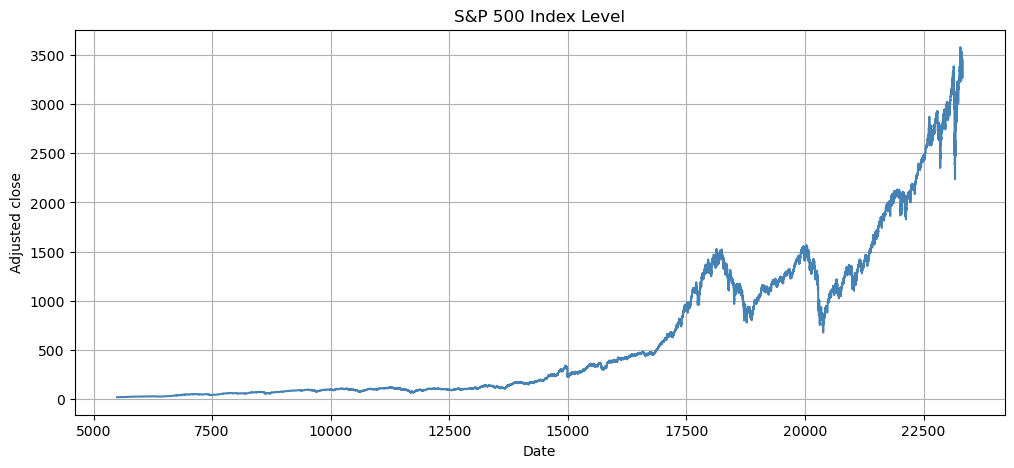

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data["Adj Close"], c="steelblue")
ax.set_title("S&P 500 Index Level")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted close")
plt.show()

Let's have a rough understanding of how the stock market fluctuates

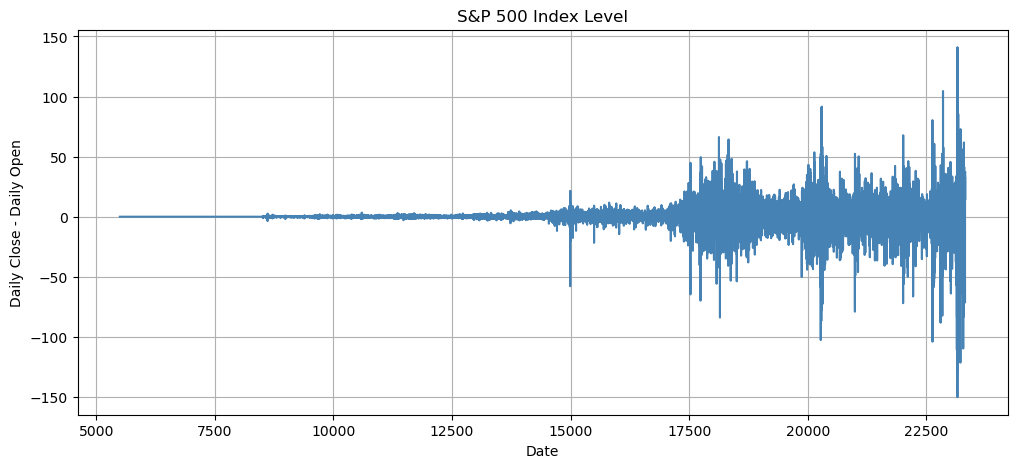

In [10]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data["Adj Close"]-data["Open"], c="steelblue")
ax.set_title("S&P 500 Index Level")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Close - Daily Open")
plt.show()



## 2. From prices to daily returns

The price level itself is not a particularly convenient random variable for our probability questions.

Instead, define the close to close return:

$
r_t = \frac{\verb|today's close - yesterday's close|}{\verb|yesterday's close|}
$

We will also look at the absolute return rate

$
|r_t|,
$

which is always nonnegative and will be useful for Markov's inequality.


In [11]:
data["Daily_Return"] = data["Adj Close"].pct_change()
data["Abs_Daily_Return"] = data["Daily_Return"].abs()

data = data.dropna()

data[["Adj Close", "Daily_Return", "Abs_Daily_Return"]].head()

,Adj Close,Daily_Return,Abs_Daily_Return
5497,16.850000,0.011405,0.011405
5498,16.930000,0.004748,0.004748
5499,16.980000,0.002953,0.002953
5500,17.080000,0.005889,0.005889
5501,17.030001,-0.002927,0.002927


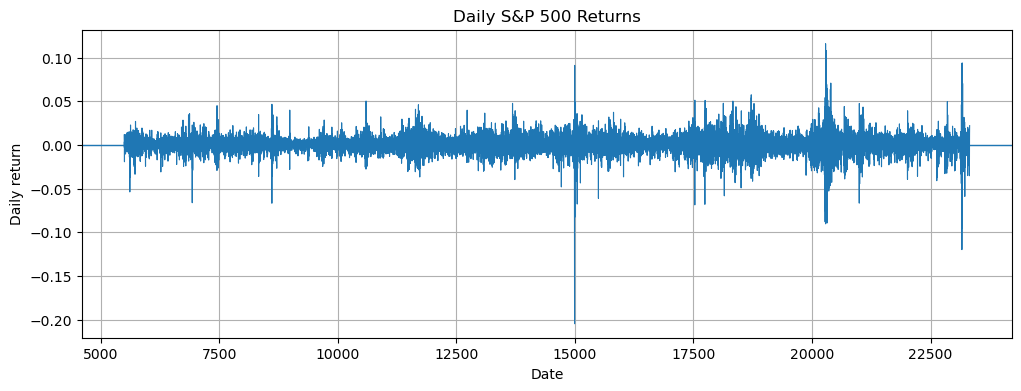

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(data.index, data["Daily_Return"], linewidth=0.8)
ax.axhline(0, linewidth=1)
ax.set_title("Daily S&P 500 Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Daily return")
plt.show()


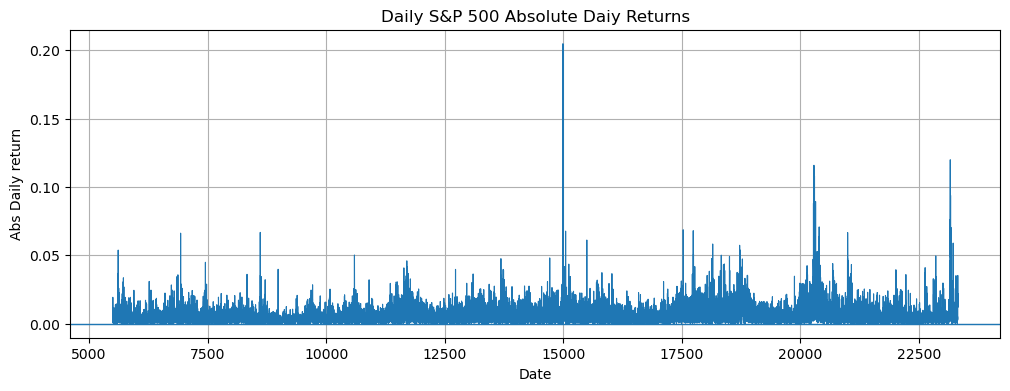

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(data.index, data["Abs_Daily_Return"], linewidth=0.8)
ax.axhline(0, linewidth=1)
ax.set_title("Daily S&P 500 Absolute Daiy Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Abs Daily return")
plt.show()

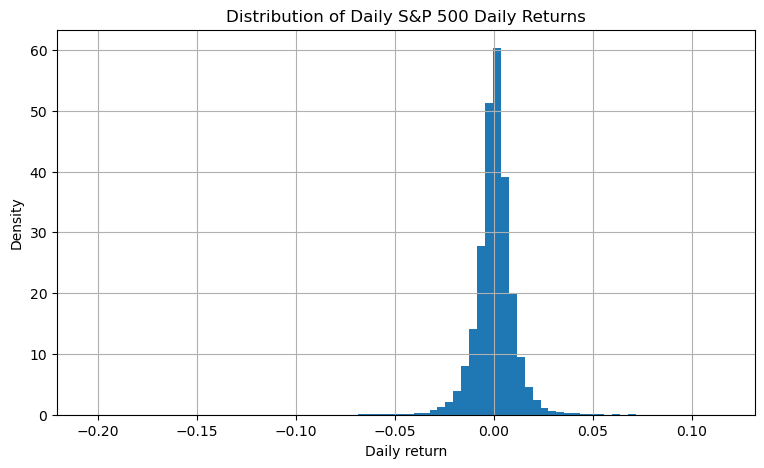

Mean daily return: 0.000348183768862715
Std. dev. daily return: 0.009880957356943987


In [14]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(data["Daily_Return"], bins=80, density=True)
ax.set_title("Distribution of Daily S&P 500 Daily Returns")
ax.set_xlabel("Daily return")
ax.set_ylabel("Density")
plt.show()

print("Mean daily return:", data["Daily_Return"].mean())
print("Std. dev. daily return:", data["Daily_Return"].std())



# Part I — Poisson: How often do rare events occur?

Suppose we define an **extreme market day** as a day for which

$
|r_t| > c.
$

For example, with c=0.025, an extreme day is one on which the S&P 500 moves by more than about 2.5% in daily return terms.

Attention! We are **not** saying that the return itself is Poisson distributed. Instead, for each block of trading days we count

$
N_i = \text{number of extreme days in block } i.
$

Then we hypothesize:

$
N_i \sim \operatorname{Poisson}(\lambda).
$

In [15]:

# Play with the threshold and see what happens
threshold = 0.025

data["extreme"] = (data["Daily_Return"].abs() > threshold).astype(int)

print(f"Threshold: {threshold:.1%}")
print(f"Number of extreme days: {data['extreme'].sum()}")
print(f"Fraction of extreme days: {data['extreme'].mean():.2%}")


Threshold: 2.5%
Number of extreme days: 416
Fraction of extreme days: 2.33%



### Why use fixed-size blocks?

A calendar month can contain different numbers of trading days. To keep the exposure approximately constant, we use blocks of **20 trading days**, roughly a month.

So we further phrase:

$$
\boxed{\text{\(N_i\) = number of extreme market days among 20 consecutive trading days.}}
$$



In [21]:

block_size = 20

# Keep only complete blocks.
n_complete = len(data) // block_size
trimmed = data.iloc[:n_complete * block_size].copy()

trimmed["block"] = np.arange(len(trimmed)) // block_size

block_counts = trimmed.groupby("block")["extreme"].sum()

block_counts.head(10)


block
0    0
1    0
2    0
3    0
4    0
5    1
6    2
7    0
8    0
9    0
Name: extreme, dtype: int64

In [22]:

lambda_hat = block_counts.mean()

print(f"Estimated Poisson rate λ: {lambda_hat:.3f}")
print(f"Sample variance of counts: {block_counts.var(ddof=1):.3f}")
print(f"Sample mean of counts:     {block_counts.mean():.3f}")


Estimated Poisson rate λ: 0.466
Sample variance of counts: 1.966
Sample mean of counts:     0.466



### Compare the empirical distribution with a Poisson model

If

$
N\sim\operatorname{Poisson}(\lambda),
$

then

$
P(N=k)=e^{-\lambda}\frac{\lambda^k}{k!}.
$

Let's compare the observed block counts with the fitted Poisson distribution.


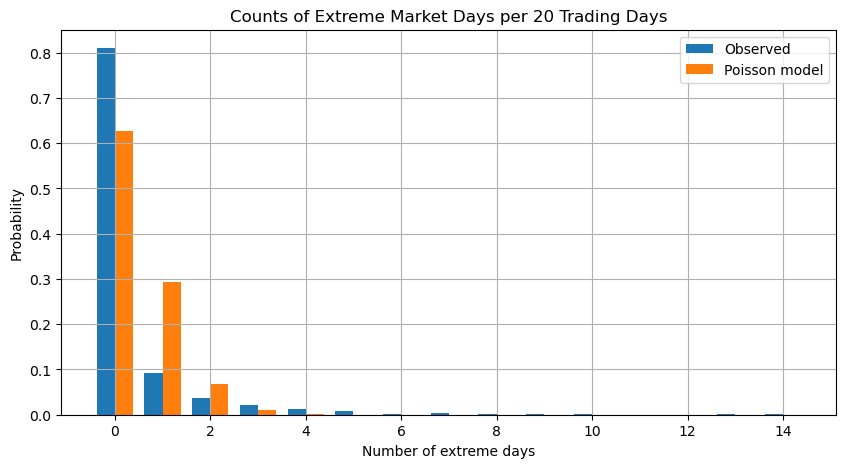

In [23]:

max_count = int(block_counts.max())
k_values = np.arange(0, max_count + 1)

observed_probs = block_counts.value_counts(normalize=True).reindex(
    k_values, fill_value=0
)
poisson_probs = poisson.pmf(k_values, mu=lambda_hat)

width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(k_values - width/2, observed_probs, width=width, label="Observed")
ax.bar(k_values + width/2, poisson_probs, width=width, label="Poisson model")
ax.set_title("Counts of Extreme Market Days per 20 Trading Days")
ax.set_xlabel("Number of extreme days")
ax.set_ylabel("Probability")
ax.legend()
plt.show()



### A probability question

Under the fitted Poisson model, what is the probability of seeing **at least 3 extreme days** in a 20-trading-day block?

$$
P(N\ge3)
=
1-P(N=0)-P(N=1)-P(N=2).
$$


In [24]:

p_at_least_3 = poisson.sf(2, mu=lambda_hat)

print(f"Fitted Poisson P(N >= 3) = {p_at_least_3:.3%}")

# Compare with the empirical probability.
empirical_at_least_3 = (block_counts >= 3).mean()
print(f"Empirical P(N >= 3)     = {empirical_at_least_3:.3%}")


Fitted Poisson P(N >= 3) = 1.193%
Empirical P(N >= 3)     = 5.948%


Wow, the numbers don't match up!

### What should we question about the Poisson model?

For a simple Poisson model, one expects

$
E[N_i]=\lambda,\qquad \operatorname{Var}(N_i)=\lambda.
$

The Poisson process also assumes a stable event rate and, in the simplest formulation, no dependence between disjoint intervals.

Financial markets can violate these assumptions. Extreme movements tend to **cluster during volatile periods**, so the observed variance of the count can exceed its mean.


In [25]:

# Quick overdispersion diagnostic
mean_count = block_counts.mean()
variance_count = block_counts.var(ddof=1)

print(f"Mean count:     {mean_count:.3f}")
print(f"Variance count: {variance_count:.3f}")
print(f"Variance / mean: {variance_count / mean_count:.3f}")


Mean count:     0.466
Variance count: 1.966
Variance / mean: 4.221


You can also play with the `Extreme Day` threshold, and see if a poisson model fits well with the new threshold.


# Part II — Markov's inequality

Markov's inequality applies to a **nonnegative** random variable \(X\):

$$
P(X\ge a)\le \frac{E[X]}{a},
\qquad a>0.
$$

Daily returns themselves can be negative, so we cannot directly use \(X=r_t\).

Instead define

$
X=|r_t|\ge0.
$

Then

$
P(|r_t|\ge a)
\le
\frac{E[|r_t|]}{a}.
$


In [28]:
mean_abs_return = data["Abs_Daily_Return"].mean()
abs_returns = data["Abs_Daily_Return"]

print(f"Estimated E[|R|] = {mean_abs_return:.5f}")
print(f"                 = {mean_abs_return:.3%}")

Estimated E[|R|] = 0.00660
                 = 0.660%


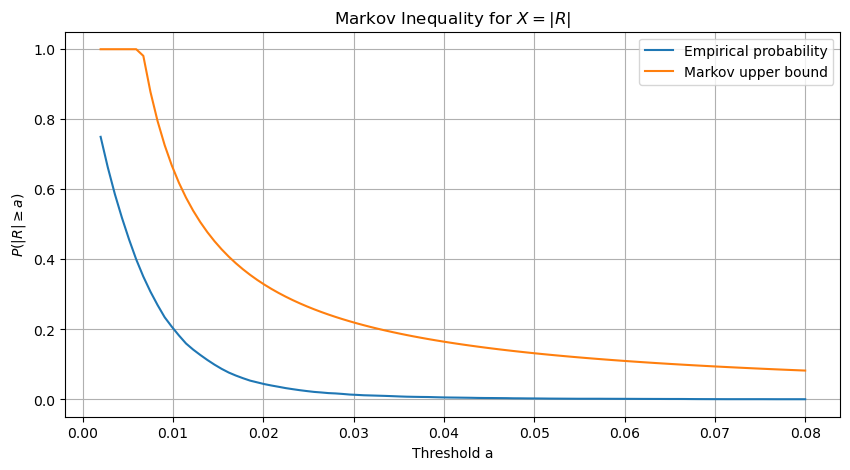

In [29]:

thresholds = np.linspace(0.002, 0.08, 100)

markov_bound = np.minimum(mean_abs_return / thresholds, 1.0)
empirical_tail = np.array([
    (abs_returns >= a).mean()
    for a in thresholds
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, empirical_tail, label="Empirical probability")
ax.plot(thresholds, markov_bound, label="Markov upper bound")
ax.set_title(r"Markov Inequality for $X=|R|$")
ax.set_xlabel("Threshold a")
ax.set_ylabel(r"$P(|R| \geq a)$")
ax.legend()
plt.show()



### Zoom in on one threshold

Suppose we ask:

> What is the probability that the absolute daily return is at least 4%?

Markov gives us a bound without assuming a normal distribution, a Student-\(t\) distribution, or any other specific shape.


In [30]:

a = 0.04

empirical = (abs_returns >= a).mean()
markov = min(mean_abs_return / a, 1.0)

print(f"Threshold:              {a:.1%}")
print(f"Empirical probability:  {empirical:.3%}")
print(f"Markov upper bound:     {markov:.3%}")


Threshold:              4.0%
Empirical probability:  0.583%
Markov upper bound:     16.500%



# Part III — Chebyshev's inequality

Chebyshev's inequality says that if a random variable has mean $\mu$ and finite variance $\sigma^2$, then

$
P(|X-\mu|\ge k\sigma)
\le
\frac{1}{k^2}.
$

For our daily returns,

$
P(|R-\mu|\ge k\sigma)\le\frac1{k^2}.
$

Notice the difference here:

- Markov: only a mean of a nonnegative variable.
- Chebyshev: mean **and** variance.


In [32]:

returns = data["Daily_Return"]

mu_hat = returns.mean()
sigma_hat = returns.std(ddof=1)

print(f"Estimated mean μ: {mu_hat:.6f}")
print(f"Estimated std σ:  {sigma_hat:.6f}")


Estimated mean μ: 0.000348
Estimated std σ:  0.009881


In [33]:

k_values = np.arange(1, 6)

chebyshev_bound = 1 / k_values**2

empirical_chebyshev = np.array([
    (np.abs(returns - mu_hat) >= k * sigma_hat).mean()
    for k in k_values
])

comparison = pd.DataFrame({
    "k": k_values,
    "Empirical probability": empirical_chebyshev,
    "Chebyshev bound": chebyshev_bound
})

comparison


,k,Empirical probability,Chebyshev bound
0,1,0.205879,1.000000
1,2,0.045832,0.250000
2,3,0.014193,0.111111
3,4,0.006059,0.062500
4,5,0.002973,0.040000


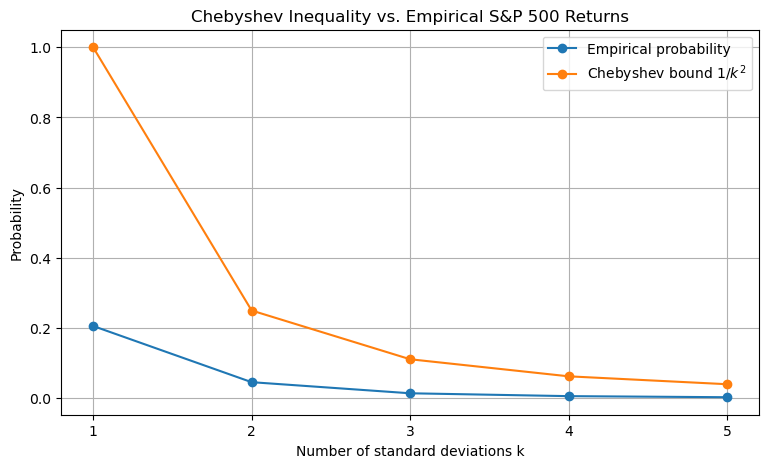

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    k_values,
    empirical_chebyshev,
    marker="o",
    label="Empirical probability"
)

ax.plot(
    k_values,
    chebyshev_bound,
    marker="o",
    label=r"Chebyshev bound $1/k^2$"
)

ax.set_xticks(k_values)
ax.set_xlabel("Number of standard deviations k")
ax.set_ylabel("Probability")
ax.set_title("Chebyshev Inequality vs. Empirical S&P 500 Returns")
ax.legend()
plt.show()



## A more visual version

For each \(k\), Chebyshev tells us that the probability outside the interval

$
[\mu-k\sigma,\;\mu+k\sigma]
$

cannot exceed $1/k^2$.

Let's visualize the case $k=2$.


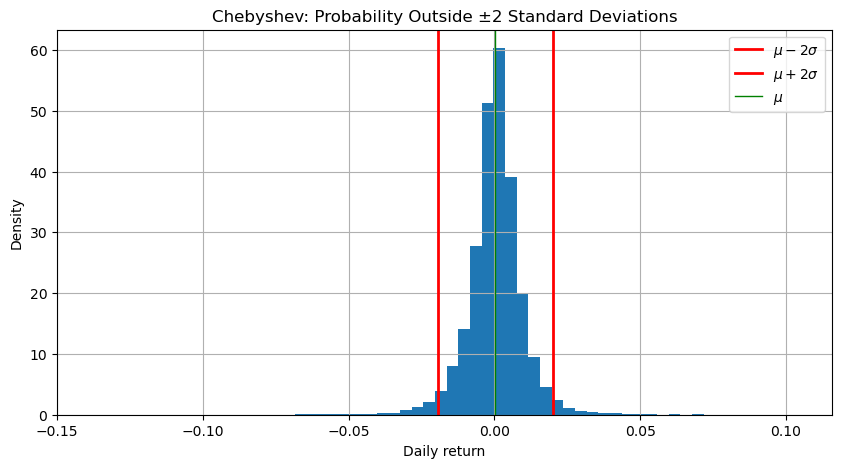

Empirical tail probability: 4.583%
Chebyshev upper bound:      25.000%


In [38]:

k = 2

lower = mu_hat - k * sigma_hat
upper = mu_hat + k * sigma_hat

empirical_prob = ((returns < lower) | (returns > upper)).mean()
cheb_bound = 1 / k**2

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(returns, bins=80, density=True)

ax.axvline(lower, linewidth=2, label=r"$\mu-2\sigma$", c= "red")
ax.axvline(upper, linewidth=2, label=r"$\mu+2\sigma$", c= "red")
ax.axvline(mu_hat, linewidth=1, label=r"$\mu$", c = "green")

ax.set_xlim(
    max(returns.min(), -0.15),
    min(returns.max(), 0.15)
)

ax.set_title("Chebyshev: Probability Outside ±2 Standard Deviations")
ax.set_xlabel("Daily return")
ax.set_ylabel("Density")
ax.legend()

plt.show()

print(f"Empirical tail probability: {empirical_prob:.3%}")
print(f"Chebyshev upper bound:      {cheb_bound:.3%}")



# Part IV — Why is Chebyshev just Markov?

This is the conceptual connection worth emphasizing in class.

Start with the event

$
|X-\mu|\ge k\sigma.
$

Square both sides:

$
(X-\mu)^2\ge k^2\sigma^2.
$

Now define

$
Y=(X-\mu)^2.
$

Since $Y\ge0$, Markov's inequality applies:

$ P(Y\ge k^2\sigma^2) \le \frac{E[Y]}{k^2\sigma^2}.$

But

$
E[Y]=E[(X-\mu)^2]=\sigma^2.
$

Therefore,

$P(|X-\mu|\ge k\sigma)\le\frac{\sigma^2}{k^2\sigma^2}=\boxed{\frac1{k^2}}.$

So:

$
\boxed{\text{Chebyshev = Markov applied to squared deviations.}}
$



# Part V — Simulation: same mean and variance, different tails

Chebyshev is especially interesting because it does **not** require the distribution to be Gaussian.

Let's construct several distributions with approximately the same mean and variance:

- Normal
- Uniform
- Student-\(t\) with heavy tails

Their shapes and tail probabilities can be very different, but Chebyshev gives a valid upper bound for all of them as long as the variance is finite.


In [39]:

rng = np.random.default_rng(42)
n = 200_000

# Generate distributions with mean approximately 0 and variance approximately 1.
normal_sample = rng.normal(0, 1, n)

uniform_sample = rng.uniform(
    -np.sqrt(3),
    np.sqrt(3),
    n
)

# Student-t with df=5 has variance 5/(5-2) = 5/3.
t_raw = rng.standard_t(df=5, size=n)
t_sample = t_raw / np.sqrt(5/3)

samples = {
    "Normal": normal_sample,
    "Uniform": uniform_sample,
    "Student-t (df=5)": t_sample,
}

for name, x in samples.items():
    print(
        f"{name:18s} "
        f"mean={x.mean(): .3f}, "
        f"variance={x.var(): .3f}"
    )


Normal             mean=-0.001, variance= 1.006
Uniform            mean=-0.002, variance= 0.999
Student-t (df=5)   mean=-0.001, variance= 0.999


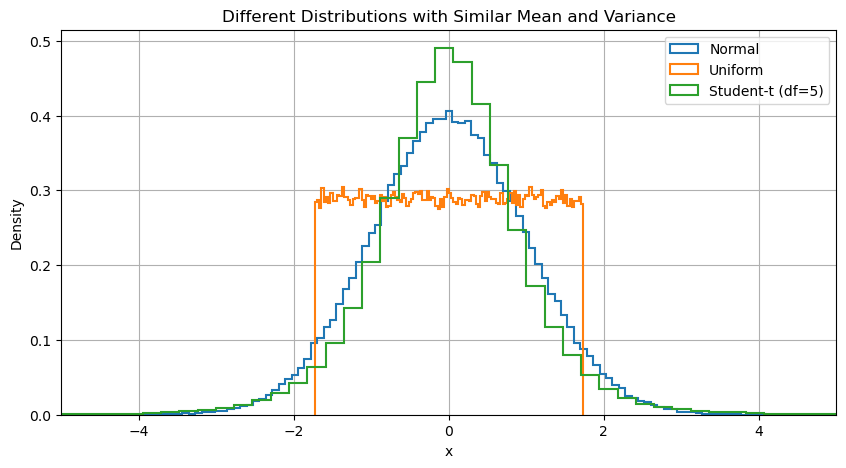

In [40]:

fig, ax = plt.subplots(figsize=(10, 5))

for name, x in samples.items():
    ax.hist(
        x,
        bins=120,
        density=True,
        histtype="step",
        linewidth=1.5,
        label=name
    )

ax.set_xlim(-5, 5)
ax.set_title("Different Distributions with Similar Mean and Variance")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.legend()

plt.show()


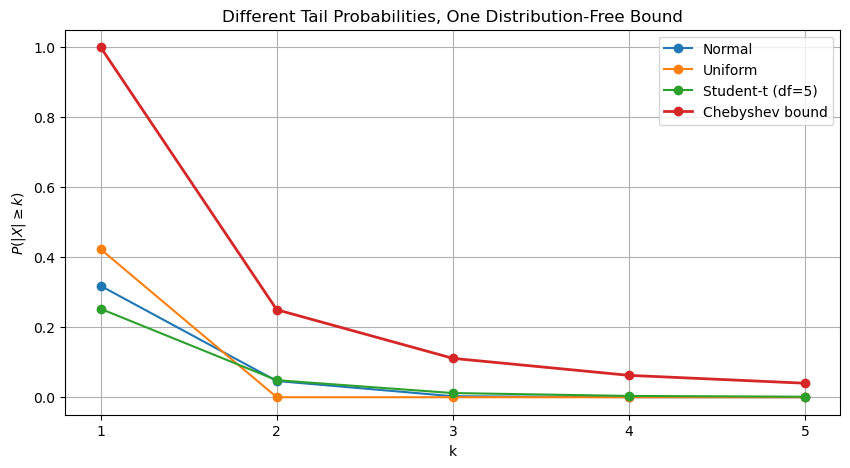

In [41]:

k_values = np.arange(1, 6)

fig, ax = plt.subplots(figsize=(10, 5))

for name, x in samples.items():
    empirical_tail = np.array([
        np.mean(np.abs(x) >= k)
        for k in k_values
    ])
    ax.plot(k_values, empirical_tail, marker="o", label=name)

ax.plot(
    k_values,
    1 / k_values**2,
    marker="o",
    linewidth=2,
    label="Chebyshev bound"
)

ax.set_xticks(k_values)
ax.set_xlabel("k")
ax.set_ylabel(r"$P(|X| \geq k)$")
ax.set_title("Different Tail Probabilities, One Distribution-Free Bound")
ax.legend()

plt.show()



## Discussion questions

1. Which simulated distribution has the heaviest tails?
2. Which distribution has the smallest tail probability at \(k=3\)?
3. Does Chebyshev tell us the *actual* probability?
4. Why can the bound be useful even when it is much larger than the actual probability?
5. What additional assumptions would allow us to obtain a sharper bound?



# Part VI — Optional student exercises

### Exercise 1: Change the definition of an extreme event

Try thresholds of

$
1.5\%,\quad 2\%,\quad 2.5\%,\quad 3\%,\quad 4\%.
$

For each threshold:

- estimate $\lambda$,
- compare the empirical count distribution with a Poisson distribution,
- calculate the variance-to-mean ratio.

**Question:** At which threshold does the Poisson approximation look most reasonable?

---

### Exercise 2: Positive vs. negative extremes

Instead of

$
|r_t|>c,
$

define two event types:

$
r_t>c
\qquad\text{and}\qquad
r_t<-c.
$

Count positive and negative extreme days separately.

**Question:** Do the two event types appear equally often?

---

### Exercise 3: Markov vs. Chebyshev

For a threshold \(a\), compare

$
P(|R|\ge a)
$

with the Markov bound

$
\frac{E|R|}{a}
$

and the Chebyshev bound obtained by choosing \(k\) so that

$
a=k\sigma.
$

**Question:** Which bound is tighter for this dataset?

---

### Exercise 4: Is a normal model appropriate?

Compare the empirical return histogram with a fitted normal distribution.

Then compare empirical tail probabilities with the normal model and Chebyshev's bound.

**Question:** Why might a normal approximation look reasonable near the center while performing poorly in the tails?



# Takeaways

### Poisson
Use it when the random quantity is a **count of events**:

\[
N\sim\operatorname{Poisson}(\lambda).
\]

Here:

> How many extreme market days occur in a fixed block of trading days?

### Markov
For \(X\ge0\),

\[
P(X\ge a)\le\frac{E[X]}{a}.
\]

Here:

> How large can the probability of a large absolute return be, given only its mean?

### Chebyshev
For a variable with finite variance,

\[
P(|X-\mu|\ge k\sigma)\le\frac1{k^2}.
\]

Here:

> How large can the probability of a large deviation be, given the mean and variance?

### The bigger statistical lesson

A useful model is not necessarily a perfectly true description of reality.

The interesting questions are:

- What exactly are we modeling?
- What assumptions are we making?
- Do the data support those assumptions?
- What do we gain from the model?
- Where does the model break down?
